In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import poisson
import numpy as np

the dataset is composed by many fatures like ;edges , circles ,ego, egofeat,feat, the main important are either edges or  circles but for this case of study we need only the edges , circles are a clustered representation of friends groups. but the lack of more contex we it wont say nothing just the clustered friends for now .

in this data set we had multiples gz ,txt , so we use the "combined txt" that has all the edges combined ,first we need to give structure to our txt using pandas , pd the data is protected by facebook

graph with networkX and how many nodes & edges

In [ ]:
df=pd.read_csv('facebook_aristas_limpio.csv', sep=' ')
G=nx.from_pandas_edgelist(df,source='source',target='target')
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 4039
Number of edges: 88234


node´s degrees for each , central desviation meassures
interpretability of var/mean near to 1 = ER , weather  var/mean > 1 too much dispersion = big tail

In [ ]:
deg=np.array([d for _, d in G.degree])


In [ ]:
def pmf_from_degrees(x): #k is the set of all x values
  k,c=np.unique(x,return_counts=True) #unique distinct values it is like clustering
  return k,c/sum(c) # a new array with the probabilities c frecuency of concurrency

PMF
graph frequency
standarization to 1
graph

In [ ]:
k_obs, pmf_obs = pmf_from_degrees(deg)
print(k_obs)
print(pmf_obs)
print(f"Suma total del PMF: {np.sum(pmf_obs)}")

[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  144  145  146  147  148  149  150  151  152  153  154  155  156
  157  158  159  160  161  162  163  164  165  166  167  168  169  170
  171  172  173  174  175  176  177  178  179  180  181  182  183  184
  185  186  187  188  189  190  191  192  193  194  195  196  197  198
  199 

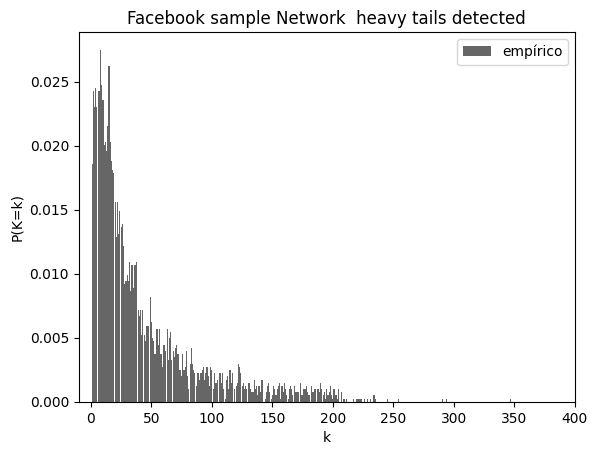

In [ ]:
lam = deg.mean()


# PMF empírica vs Poisson(λ̂)
k_emp, pmf_emp = pmf_from_degrees(deg)

plt.figure()
plt.bar(k_emp, pmf_emp, width=0.9, align="center", alpha=0.6, label="empírico",color='black')
plt.xlim(-10,400)
plt.xlabel("k"); plt.ylabel("P(K=k)"); plt.title("Facebook sample Network  heavy tails detected "); plt.legend()
plt.show()

CCDF
p(K>=k)
lineal scale and logarithm transformation
logartihm (linear scale "big tails" or southward curve )

In [ ]:
def ccd_from_degrees(x):
  k,pmf=pmf_from_degrees(x)
  ccdf=np.flip(np.cumsum(np.flip(pmf))) #the cumulative sum of degrees probabilities
  return k,ccdf

In [ ]:
k_ccdf, ccdf_obs = ccd_from_degrees(deg)
print(k_ccdf)
print(ccdf_obs)
print(f"Primer valor de la CCDF (P(K >= min_k)): {ccdf_obs[0]}")

[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  144  145  146  147  148  149  150  151  152  153  154  155  156
  157  158  159  160  161  162  163  164  165  166  167  168  169  170
  171  172  173  174  175  176  177  178  179  180  181  182  183  184
  185  186  187  188  189  190  191  192  193  194  195  196  197  198
  199 

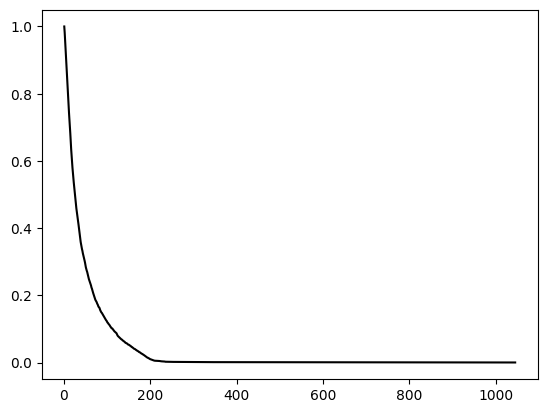

In [ ]:
plt.figure()
plt.plot(k_ccdf, ccdf_obs, label="CCDF",color='black')

FINDING THE HUBS

top 1% hubs nodes
top 5%
top 10%
#how similar are they to BA , is there any popular node?

In [ ]:
node_degrees_list = sorted(list(G.degree()), key=lambda x: x[1], reverse=True)

num_nodes = G.number_of_nodes()

top_1_percent_count = int(0.01 * num_nodes)
top_5_percent_count = int(0.05 * num_nodes)
top_10_percent_count = int(0.10 * num_nodes)

threshold_1_percent_degree = node_degrees_list[top_1_percent_count - 1][1] if top_1_percent_count > 0 else 0
threshold_5_percent_degree = node_degrees_list[top_5_percent_count - 1][1] if top_5_percent_count > 0 else 0
threshold_10_percent_degree = node_degrees_list[top_10_percent_count - 1][1] if top_10_percent_count > 0 else 0


hubs_1_percent = [node for node, degree in G.degree() if degree >= threshold_1_percent_degree]
hubs_5_percent = [node for node, degree in G.degree() if degree >= threshold_5_percent_degree]
hubs_10_percent = [node for node, degree in G.degree() if degree >= threshold_10_percent_degree]


print(f"Total nodes {num_nodes}")
hub=max(deg)
print(f"as you can see the biggest the most popular \n hub of the whole sample has {hub} conexions (degrees)")
print(f"\nTop 1% Hubs:")
print(f"  Number of nodes  {len(hubs_1_percent)}")
print(f"  Minimum degree for 1% hubs: {threshold_1_percent_degree}")

print(f"\nTop 5% Hubs:")
print(f"  Number of nodes: {len(hubs_5_percent)}")
print(f"  Minimum degree for 5% hubs: {threshold_5_percent_degree}")

print(f"\nTop 10% Hubs ")
print(f"  Number of nodes  {len(hubs_10_percent)}")
print(f"  Minimum degree for 10% hubs  {threshold_10_percent_degree}")


Total nodes 4039
as you can see the biggest the most popular 
 hub of the whole sample has 1045 conexions (degrees)

Top 1% Hubs:
  Number of nodes  40
  Minimum degree for 1% hubs: 201

Top 5% Hubs:
  Number of nodes: 202
  Minimum degree for 5% hubs: 154

Top 10% Hubs 
  Number of nodes  404
  Minimum degree for 10% hubs  113


POISSON VS THEORETICAL VALUES OF PMF

P(K=k) =(e´(-mean) mean´k )/ k¡

" noticed that y axe data variation is ok while axe x is the same"



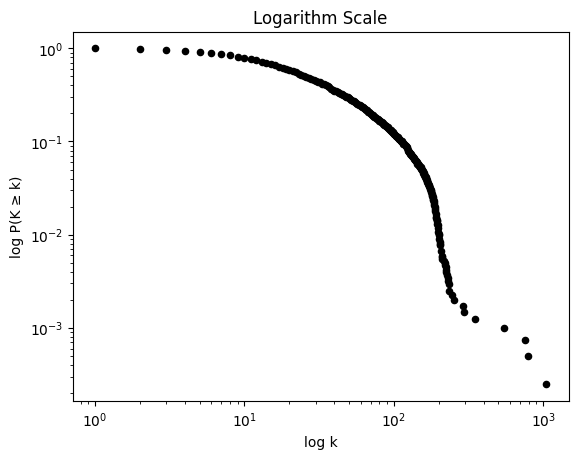

In [ ]:
# log–log: puntos
mask_g = (k_obs > 0) & (ccdf_obs > 0)
#

plt.figure()
plt.scatter(k_obs[mask_g], ccdf_obs[mask_g], s=20,color='black')
plt.xscale("log"); plt.yscale("log")
plt.xlabel("log k"); plt.ylabel("log P(K ≥ k)"); plt.title("Logarithm Scale")
plt.show()

we have not only simple Barabasi albert, we have a complex relation between our nodes , we have big tails

In [ ]:
lam = deg.mean()
var = deg.var()
std = deg.std()
print(f"lambda 'degree´s mean' = {lam:.2f}, var= {var:.2f} std={std:.2f}")

lambda 'degree´s mean' = 43.69, var= 2747.24 std=52.41


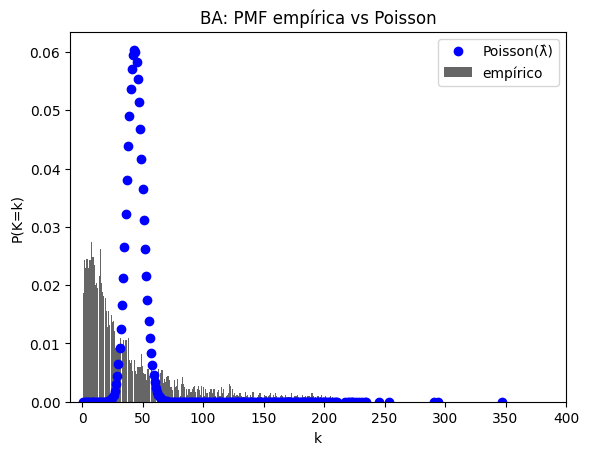

In [ ]:
k_emp,pmf_emp=pmf_from_degrees(deg)
pmf_mod = poisson.pmf(k_emp, mu=lam)
plt.figure()
plt.xlim(-10,400)
plt.bar(k_emp, pmf_emp, width=0.9, align="center", alpha=0.6, label="empírico",color='black')
plt.plot(k_emp, pmf_mod, marker="o", linestyle="none", label="Poisson(λ̂)",color='blue')
plt.xlabel("k"); plt.ylabel("P(K=k)"); plt.title("BA: PMF empírica vs Poisson"); plt.legend()
plt.show()

x label *matches*!

CONCLUTIONS; facebook´s sample network is a BA type,

 we have a variance of 2747.24, wich means that there is a big separation energy, "big tails are pulling";moreover, in the graphic representation there is a hub nodes wich are k>300 , being the popular one with 1045 degrees,



 poisson distributiton matches too with label x,


with these methods we can find the most influent node of our sample , it is important to have the contex and the right edges data, even we can enrich the node for the sake of  better insights.